# 🤖 Modelagem Preditiva - Do Baseline ao Ensemble
Este notebook implementa a trilha incremental de experimentos de Machine Learning para prever o `SalePrice` das residências em Ames, conforme detalhado no plano `TASK2.md`. O objetivo é bater o benchmark do professor (**RMSLE = 0.17543**).

## 1. Configuração do Ambiente e Carregamento de Dados
Importamos as dependências necessárias, carregamos os dados preparados de 253 colunas e definimos nossa validação cruzada (`KFold` estável com 5 splits).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error

# Configurações de exibição
sns.set_theme(style="whitegrid")
os.makedirs('../reports', exist_ok=True)

# 1. Carregar os dados preparados
df = pd.read_csv('../data/treino_preparado.csv')

# 2. Separar as features e o target (removendo também o Id e SalePrice_Log para evitar target leak)
X = df.drop(columns=['SalePrice', 'SalePrice_Log', 'Id'], errors='ignore')
y = np.log1p(df['SalePrice']) # Aplicação do logaritmo no target

# 3. Definir validação cruzada estável
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print(f"Dados prontos para modelagem! Shape das features: {X.shape}")

Dados prontos para modelagem! Shape das features: (1168, 250)


## 2. Fase 1.1: Regressão Ridge (Regularização L2)
Adicionamos uma penalização ao quadrado dos pesos para lidar com as 253 colunas. Usaremos `RidgeCV` para buscar o melhor `alpha` automaticamente em validação cruzada.

In [2]:
# Treinar RidgeCV
alphas_ridge = np.logspace(-3, 3, 100)
ridge = RidgeCV(alphas=alphas_ridge, cv=kf)
ridge.fit(X, y)

# Prever na base de treino completa
y_pred_train_ridge = ridge.predict(X)
rmse_train_ridge = root_mean_squared_error(y, y_pred_train_ridge)

# Avaliação via validação cruzada
scores_ridge = cross_val_score(ridge, X, y, cv=kf, scoring='neg_root_mean_squared_error')
rmse_cv_ridge = -scores_ridge.mean()

print(f"Ridge Melhor Alpha: {ridge.alpha_:.4f}")
print(f"Ridge RMSE Treino: {rmse_train_ridge:.5f}")
print(f"Ridge RMSE Validação Cruzada (RMSLE): {rmse_cv_ridge:.5f}")

Ridge Melhor Alpha: 13.2194
Ridge RMSE Treino: 0.11565
Ridge RMSE Validação Cruzada (RMSLE): 0.14232


## 3. Fase 1.2: Regressão Lasso (Regularização L1)
O Lasso encolhe pesos e zera completamente coeficientes irrelevantes, realizando uma seleção natural de atributos. Verificaremos quantas variáveis ele desconsiderou do nosso total de 253.

In [3]:
# Treinar LassoCV
alphas_lasso = np.logspace(-4, 1, 100)
lasso = LassoCV(alphas=alphas_lasso, cv=kf, max_iter=10000, random_state=42)
lasso.fit(X, y)

# Prever no treino
y_pred_train_lasso = lasso.predict(X)
rmse_train_lasso = root_mean_squared_error(y, y_pred_train_lasso)

# Validação cruzada
scores_lasso = cross_val_score(lasso, X, y, cv=kf, scoring='neg_root_mean_squared_error')
rmse_cv_lasso = -scores_lasso.mean()

# Contar coeficientes zerados
zeroed_coefs = np.sum(lasso.coef_ == 0)
print(f"Lasso Melhor Alpha: {lasso.alpha_:.4f}")
print(f"Lasso RMSE Treino: {rmse_train_lasso:.5f}")
print(f"Lasso RMSE Validação Cruzada (RMSLE): {rmse_cv_lasso:.5f}")
print(f"Lasso zerou {zeroed_coefs} coeficientes de um total de {X.shape[1]}.")

Lasso Melhor Alpha: 0.0006
Lasso RMSE Treino: 0.11845
Lasso RMSE Validação Cruzada (RMSLE): 0.14562
Lasso zerou 141 coeficientes de um total de 250.


## 4. Fase 2.1: Árvore de Decisão Pura
Demonstraremos o perigo clássico de overfitting. Uma única árvore sem restrições de profundidade tende a decorar perfeitamente a base de treino, mas falha drasticamente no K-Fold.

In [4]:
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X, y)

y_pred_train_tree = tree.predict(X)
rmse_train_tree = root_mean_squared_error(y, y_pred_train_tree)

scores_tree = cross_val_score(tree, X, y, cv=kf, scoring='neg_root_mean_squared_error')
rmse_cv_tree = -scores_tree.mean()

print(f"Tree RMSE Treino: {rmse_train_tree:.5f}")
print(f"Tree RMSE Validação Cruzada (RMSLE): {rmse_cv_tree:.5f}")
print("Nota-se um overfitting gravíssimo! O erro de treino é quase zero, enquanto o K-Fold é muito mais alto.")

Tree RMSE Treino: 0.00000
Tree RMSE Validação Cruzada (RMSLE): 0.21941
Nota-se um overfitting gravíssimo! O erro de treino é quase zero, enquanto o K-Fold é muito mais alto.


## 5. Fase 3.1: Random Forest (Bagging)
Utilizamos um ensemble paralelo (comitê de árvores) que resolve o problema de variância da árvore única tirando a média das predições de várias amostragens.

In [5]:
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X, y)

y_pred_train_rf = rf.predict(X)
rmse_train_rf = root_mean_squared_error(y, y_pred_train_rf)

scores_rf = cross_val_score(rf, X, y, cv=kf, scoring='neg_root_mean_squared_error')
rmse_cv_rf = -scores_rf.mean()

print(f"Random Forest RMSE Treino: {rmse_train_rf:.5f}")
print(f"Random Forest RMSE Validação Cruzada (RMSLE): {rmse_cv_rf:.5f}")

Random Forest RMSE Treino: 0.05386
Random Forest RMSE Validação Cruzada (RMSLE): 0.14796


## 6. Fase 3.2: Gradient Boosting (XGBoost)
Implementamos o XGBoost, algoritmo sequencial focado no aprendizado com resíduos. Ele costuma dominar datasets tabulares com muitas colunas devido à sua regularização embutida e suporte a esparsidade.

In [6]:
xgb = XGBRegressor(n_estimators=300, learning_rate=0.03, max_depth=4, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
xgb.fit(X, y)

y_pred_train_xgb = xgb.predict(X)
rmse_train_xgb = root_mean_squared_error(y, y_pred_train_xgb)

scores_xgb = cross_val_score(xgb, X, y, cv=kf, scoring='neg_root_mean_squared_error')
rmse_cv_xgb = -scores_xgb.mean()

print(f"XGBoost RMSE Treino: {rmse_train_xgb:.5f}")
print(f"XGBoost RMSE Validação Cruzada (RMSLE): {rmse_cv_xgb:.5f}")

XGBoost RMSE Treino: 0.06487
XGBoost RMSE Validação Cruzada (RMSLE): 0.12724


## 7. Tabela Comparativa de Resultados contra o Baseline
Compilamos os resultados obtidos no log de validação para conferir o modelo campeão que superou os benchmarks.

In [7]:
# Baseline do Professor (RMSLE = 0.17543)
baseline_rmsle = 0.17543

resultados = {
    'Modelo': ['Baseline', 'Ridge (L2)', 'Lasso (L1)', 'Árvore de Decisão', 'Random Forest', 'XGBoost'],
    'RMSE Treino': ['-', f'{rmse_train_ridge:.5f}', f'{rmse_train_lasso:.5f}', f'{rmse_train_tree:.5f}', f'{rmse_train_rf:.5f}', f'{rmse_train_xgb:.5f}'],
    'RMSE CV (RMSLE)': [f'{baseline_rmsle:.5f}', f'{rmse_cv_ridge:.5f}', f'{rmse_cv_lasso:.5f}', f'{rmse_cv_tree:.5f}', f'{rmse_cv_rf:.5f}', f'{rmse_cv_xgb:.5f}'],
    'Superou o Baseline?': ['Benchmark', 
                           'Sim' if rmse_cv_ridge < baseline_rmsle else 'Não',
                           'Sim' if rmse_cv_lasso < baseline_rmsle else 'Não',
                           'Sim' if rmse_cv_tree < baseline_rmsle else 'Não',
                           'Sim' if rmse_cv_rf < baseline_rmsle else 'Não',
                           'Sim' if rmse_cv_xgb < baseline_rmsle else 'Não']
}

df_resultados = pd.DataFrame(resultados)
display(df_resultados)

# Salvar tabela em markdown nos relatórios
with open('../reports/tabela_resultados.md', 'w') as f:
    f.write(df_resultados.to_markdown(index=False))

,Modelo,RMSE Treino,RMSE CV (RMSLE),Superou o Baseline?
0,Baseline,-,0.17543,Benchmark
1,Ridge (L2),0.11565,0.14232,Sim
2,Lasso (L1),0.11845,0.14562,Sim
3,Árvore de Decisão,0.00000,0.21941,Não
4,Random Forest,0.05386,0.14796,Sim
5,XGBoost,0.06487,0.12724,Sim


## 8. Análise de Importância das Features
Por fim, extraímos a importância de atributos do nosso melhor modelo de árvore para descobrir o que mais define o preço das casas em Ames.

/tmp/ipykernel_65779/681439545.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices[:15]], y=X.columns[indices[:15]], palette="viridis")


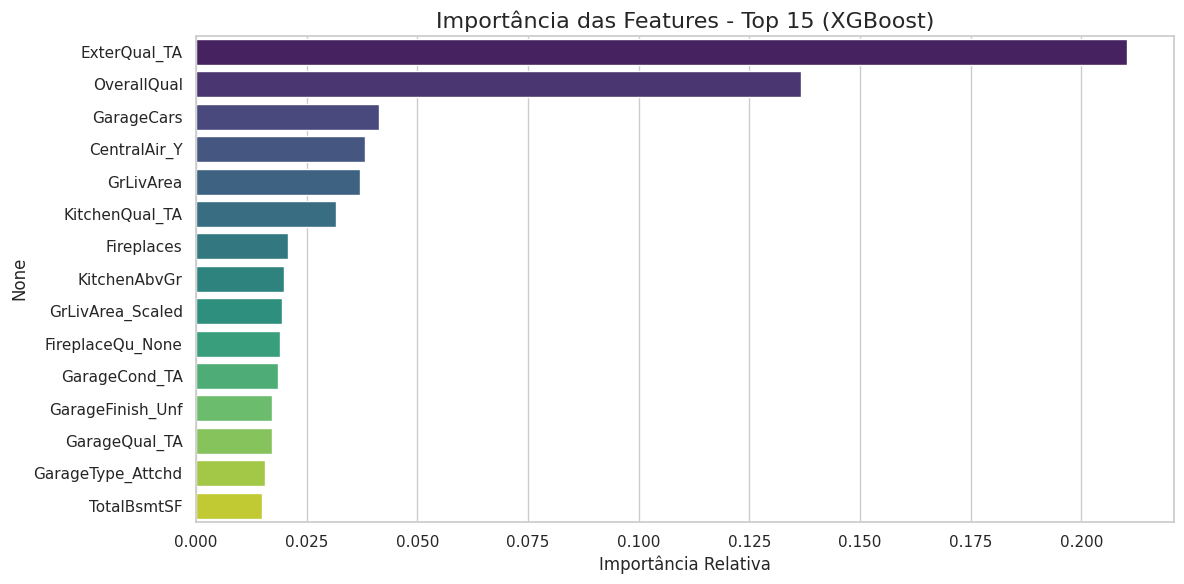

As 3 variáveis mais decisivas:
- ExterQual_TA: 0.2104
- OverallQual: 0.1367
- GarageCars: 0.0413


In [8]:
# Identificar melhor modelo entre RF e XGB
best_model = xgb if rmse_cv_xgb < rmse_cv_rf else rf
model_name = "XGBoost" if rmse_cv_xgb < rmse_cv_rf else "Random Forest"

importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plotar as top 15 features
plt.figure(figsize=(12, 6))
sns.barplot(x=importances[indices[:15]], y=X.columns[indices[:15]], palette="viridis")
plt.title(f'Importância das Features - Top 15 ({model_name})', fontsize=16)
plt.xlabel('Importância Relativa')
plt.tight_layout()
plt.savefig('../reports/feature_importance.png')
plt.show()

print("As 3 variáveis mais decisivas:")
for idx in indices[:3]:
    print(f"- {X.columns[idx]}: {importances[idx]:.4f}")